<a href="https://colab.research.google.com/github/juhee0528-lang/0528/blob/main/lending_club.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lending Club 최종 분석 코드

## 연구 가설

> **Lending Club의 기존 신용등급 중심 심사보다, 대출 신청 시점의 다양한 정보를 활용한 머신러닝 심사 전략이 포트폴리오의 Sharpe Ratio를 높일 것이다.**

이 노트북은 다음 세 전략을 비교합니다.

1. **All-loans benchmark**: 분석 대상 대출을 모두 투자한 경우
2. **Traditional baseline**: `grade`, `sub_grade`, `int_rate` 등 Lending Club의 기존 판단 정보를 이용한 모델
3. **Proposed model**: 기존 등급·금리를 제외하고 신청 시점에 알 수 있는 다양한 차주 정보를 이용한 모델
4. **Hybrid model**: 기존 판단 정보와 다양한 정보를 모두 이용한 참고 모델

또한 다음 내용을 포함합니다.

- 미해결 대출 제거 및 부도 타겟 생성
- 사후변수·누수변수 제거
- 시간순 Train/Validation/Test 분리
- EDA와 결측치 점검
- 로그변환 및 신용이력 파생변수
- Logistic Regression, Random Forest, LightGBM 비교
- Validation 데이터에서 Sharpe Ratio 최대 임계값 선택
- Test 데이터에서 최종 성과 비교
- Bootstrap 신뢰구간
- Feature importance
- Leakage 포함 전후 진단 실험

In [4]:
# Colab package installation
!pip -q install lightgbm numpy-financial

In [5]:
import io
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. 분석 설정

`RETURN_METRIC`은 기본적으로 실제 회수금액을 이용한 단순 실현수익률을 사용합니다.

- `simple_return`: `(total_pymnt_inv - funded_amnt_inv) / funded_amnt_inv`
- `approx_annual_irr`: 월별 현금흐름을 정확히 알 수 없으므로 `installment`, `total_pymnt_inv`, `term`으로 근사한 연환산 IRR

IRR은 근사치이므로, 교수님이 별도의 정확한 현금흐름 산식을 제공하지 않았다면 `simple_return`을 주 분석으로 두고 IRR은 민감도 분석으로 제시하는 것이 안전합니다.

In [6]:
# =========================
# USER CONFIGURATION
# =========================

RANDOM_STATE = 42

# Time split
TRAIN_END_YEAR = 2014
VALID_YEAR = 2015
TEST_YEAR = 2016

# Preprocessing
MISSING_THRESHOLD = 0.50
MAX_CATEGORY_LEVELS = 60
CORR_THRESHOLD = 0.90  # Change to 0.70 if the team explicitly decides to use 0.70

# Portfolio rule
THRESHOLD_GRID = np.round(np.arange(0.01, 0.81, 0.01), 2)
MIN_APPROVAL_RATE = 0.10
MIN_APPROVED_LOANS = 100

# Return calculation
RETURN_METRIC = "simple_return"  # "simple_return" or "approx_annual_irr"
RISK_FREE_RATE = 0.0

# Bootstrap
N_BOOTSTRAPS = 300

print("Configuration loaded.")

Configuration loaded.


## 2. CSV 업로드 및 로드

In [7]:
CSV_PATH = "lending_club_2020_train.csv"
raw = pd.read_csv(CSV_PATH, low_memory=False)

print("Raw shape:", raw.shape)
display(raw.head())

Raw shape: (1142027, 141)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,124989905,"6,000.0000","6,000.0000","6,000.0000",36 months,7.97%,187.9400,A,A5,Teacher,2 years,MORTGAGE,"45,000.0000",Verified,Dec-2017,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,554xx,MN,8.6700,1.0000,Sep-2005,755.0000,759.0000,0.0000,22.0000,NaN,14.0000,0.0000,"3,090.0000",14%,36.0000,w,0.0000,0.0000,"6,718.8400","6,718.8400","6,000.0000",718.8400,0.0000,0.0000,0.0000,Apr-2020,"1,835.0600",NaN,Apr-2020,764.0000,760.0000,0.0000,NaN,1.0000,Joint App,"100,500.0000",10.2000,Verified,0.0000,0.0000,"50,054.0000",1.0000,10.0000,3.0000,3.0000,3.0000,"46,964.0000",83.0000,1.0000,1.0000,"3,090.0000",64.0000,"22,100.0000",1.0000,0.0000,2.0000,4.0000,"3,850.0000","11,910.0000",20.6000,0.0000,0.0000,147.0000,135.0000,12.0000,3.0000,1.0000,56.0000,NaN,3.0000,NaN,0.0000,1.0000,1.0000,1.0000,4.0000,28.0000,4.0000,7.0000,1.0000,14.0000,0.0000,0.0000,0.0000,4.0000,97.1000,0.0000,0.0000,0.0000,"78,611.0000","50,054.0000","15,000.0000","56,511.0000","3,926.0000",555.0000,559.0000,Sep-2005,0.0000,0.0000,10.0000,NaN,10.0000,4.0000,1.0000,0.0000,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,139665484,"35,000.0000","35,000.0000","35,000.0000",60 months,14.47%,822.9500,C,C2,Product Specialist,2 years,RENT,"94,000.0000",Source Verified,Sep-2018,Current,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Credit card refinancing,085xx,NJ,17.4100,0.0000,Dec-2002,715.0000,719.0000,2.0000,NaN,NaN,6.0000,0.0000,"24,640.0000",35.4%,8.0000,w,"25,993.3200","25,993.3200","16,430.8600","16,430.8600","9,006.6800","7,424.1800",0.0000,0.0000,0.0000,May-2020,822.9500,Jun-2020,May-2020,754.0000,750.0000,0.0000,NaN,1.0000,Individual,NaN,NaN,NaN,0.0000,0.0000,"58,284.0000",1.0000,1.0000,1.

## 3. 기본 열 확인과 타겟 생성

정상 상환은 `Fully Paid`, 부도는 `Charged Off` 또는 `Default`로 정의합니다.  
현재 진행 중이거나 결과가 확정되지 않은 대출은 제외합니다.

In [8]:
def normalize_column_names(df):
    result = df.copy()
    result.columns = (
        result.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return result


def clean_percentage(series):
    if series.dtype == "object":
        return pd.to_numeric(
            series.astype(str).str.replace("%", "", regex=False).str.strip(),
            errors="coerce",
        )
    return pd.to_numeric(series, errors="coerce")


def parse_term_months(series):
    return pd.to_numeric(
        series.astype(str).str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )


def build_target(df):
    if "loan_status" not in df.columns:
        raise KeyError("Required column 'loan_status' is missing.")

    status = df["loan_status"].astype(str).str.strip()
    default_statuses = {"Charged Off", "Default"}
    paid_statuses = {"Fully Paid"}

    keep_mask = status.isin(default_statuses | paid_statuses)
    result = df.loc[keep_mask].copy()
    result["default"] = result["loan_status"].isin(default_statuses).astype(int)
    return result


df = normalize_column_names(raw)
df = build_target(df)

print("Resolved-loan shape:", df.shape)
print(df["loan_status"].value_counts(dropna=False))
print("\nDefault rate:", df["default"].mean())

Resolved-loan shape: (726287, 142)
loan_status
Fully Paid     584695
Charged Off    141423
Default           169
Name: count, dtype: int64

Default rate: 0.19495323474053644


## 4. 날짜·수익률·파생변수 생성

In [9]:
def add_date_features(df):
    result = df.copy()

    if "issue_d" in result.columns:
        result["issue_date"] = pd.to_datetime(
            result["issue_d"], format="%b-%Y", errors="coerce"
        )
        fallback = pd.to_datetime(result["issue_d"], errors="coerce")
        result["issue_date"] = result["issue_date"].fillna(fallback)
        result["issue_year"] = result["issue_date"].dt.year
        result["issue_month"] = result["issue_date"].dt.month

    if "earliest_cr_line" in result.columns:
        result["earliest_credit_date"] = pd.to_datetime(
            result["earliest_cr_line"], format="%b-%Y", errors="coerce"
        )
        fallback = pd.to_datetime(result["earliest_cr_line"], errors="coerce")
        result["earliest_credit_date"] = result["earliest_credit_date"].fillna(fallback)

        if "issue_date" in result.columns:
            result["credit_history_years"] = (
                result["issue_date"] - result["earliest_credit_date"]
            ).dt.days / 365.25
            result.loc[result["credit_history_years"] < 0, "credit_history_years"] = np.nan

    return result


def add_numeric_features(df):
    result = df.copy()

    percentage_columns = [
        "int_rate", "revol_util", "pct_tl_nvr_dlq", "percent_bc_gt_75"
    ]
    for col in percentage_columns:
        if col in result.columns:
            result[col] = clean_percentage(result[col])

    if "term" in result.columns:
        result["term_months"] = parse_term_months(result["term"])

    log_candidates = ["annual_inc", "loan_amnt", "funded_amnt", "funded_amnt_inv"]
    for col in log_candidates:
        if col in result.columns:
            numeric = pd.to_numeric(result[col], errors="coerce")
            result[f"log_{col}"] = np.log1p(numeric.clip(lower=0))

    if {"annual_inc", "loan_amnt"}.issubset(result.columns):
        annual_inc = pd.to_numeric(result["annual_inc"], errors="coerce")
        loan_amnt = pd.to_numeric(result["loan_amnt"], errors="coerce")
        result["loan_to_income"] = loan_amnt / annual_inc.replace(0, np.nan)

    if {"revol_bal", "annual_inc"}.issubset(result.columns):
        revol_bal = pd.to_numeric(result["revol_bal"], errors="coerce")
        annual_inc = pd.to_numeric(result["annual_inc"], errors="coerce")
        result["revol_balance_to_income"] = revol_bal / annual_inc.replace(0, np.nan)

    return result


def calculate_simple_return(df):
    invested_col = None
    paid_col = None

    for candidate in ["funded_amnt_inv", "funded_amnt", "loan_amnt"]:
        if candidate in df.columns:
            invested_col = candidate
            break

    for candidate in ["total_pymnt_inv", "total_pymnt"]:
        if candidate in df.columns:
            paid_col = candidate
            break

    if invested_col is None or paid_col is None:
        raise KeyError(
            "Return calculation requires an invested amount column and "
            "a total payment column."
        )

    invested = pd.to_numeric(df[invested_col], errors="coerce")
    paid = pd.to_numeric(df[paid_col], errors="coerce")
    return (paid - invested) / invested.replace(0, np.nan)


def approximate_annual_irr_row(row):
    required = ["installment", "term_months"]
    if not all(col in row.index for col in required):
        return np.nan

    invested = np.nan
    total_paid = np.nan

    for col in ["funded_amnt_inv", "funded_amnt", "loan_amnt"]:
        if col in row.index and pd.notna(row[col]):
            invested = pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0]
            break

    for col in ["total_pymnt_inv", "total_pymnt"]:
        if col in row.index and pd.notna(row[col]):
            total_paid = pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0]
            break

    installment = pd.to_numeric(pd.Series([row["installment"]]), errors="coerce").iloc[0]
    term_months = pd.to_numeric(pd.Series([row["term_months"]]), errors="coerce").iloc[0]

    if (
        pd.isna(invested) or invested <= 0
        or pd.isna(total_paid) or total_paid < 0
        or pd.isna(installment) or installment <= 0
        or pd.isna(term_months) or term_months <= 0
    ):
        return np.nan

    term_months = int(term_months)
    full_months = min(int(total_paid // installment), term_months)
    residual = total_paid - full_months * installment

    cash_flows = [-float(invested)] + [float(installment)] * full_months

    if residual > 1e-8 and full_months < term_months:
        cash_flows.append(float(residual))

    if len(cash_flows) < 2:
        return -1.0

    monthly_irr = npf.irr(cash_flows)
    if not np.isfinite(monthly_irr) or monthly_irr <= -1:
        return np.nan

    return (1 + monthly_irr) ** 12 - 1


df = add_date_features(df)
df = add_numeric_features(df)
df["simple_return"] = calculate_simple_return(df)

if RETURN_METRIC == "approx_annual_irr":
    print("Calculating approximate annual IRR. This may take several minutes.")
    df["approx_annual_irr"] = df.apply(approximate_annual_irr_row, axis=1)
    df["portfolio_return"] = df["approx_annual_irr"]
else:
    df["portfolio_return"] = df["simple_return"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df[df["portfolio_return"].notna()].copy()

# Robust diagnostic flag; do not silently remove extreme returns without reporting them.
q_low, q_high = df["portfolio_return"].quantile([0.001, 0.999])
df["extreme_return_flag"] = (
    (df["portfolio_return"] < q_low) | (df["portfolio_return"] > q_high)
).astype(int)

print(df[["simple_return", "portfolio_return"]].describe())
print("Extreme return rows:", df["extreme_return_flag"].sum())

       simple_return  portfolio_return
count   726,241.0000      726,241.0000
mean          0.0454            0.0454
std           0.2877            0.2877
min          -1.0000           -1.0000
25%           0.0404            0.0404
50%           0.1167            0.1167
75%           0.1922            0.1922
max           0.9328            0.9328
Extreme return rows: 1454


## 5. EDA

이 단계는 결과를 만드는 단계가 아니라, 타겟 불균형·등급별 부도율·수익률 이상치·결측치를 확인하는 단계입니다.

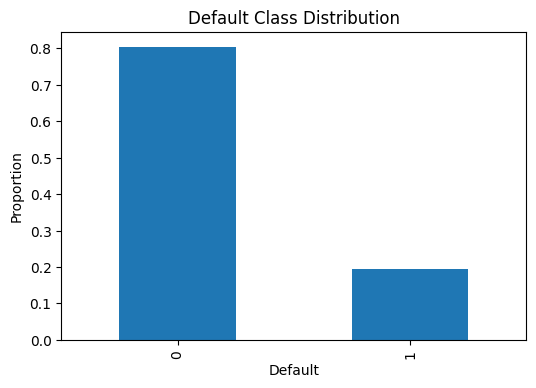

,count,mean
grade,,
A,135443,0.0649
B,213374,0.1348
C,206104,0.2235
D,106933,0.3014
E,45573,0.3757
F,14575,0.4425
G,4239,0.5105


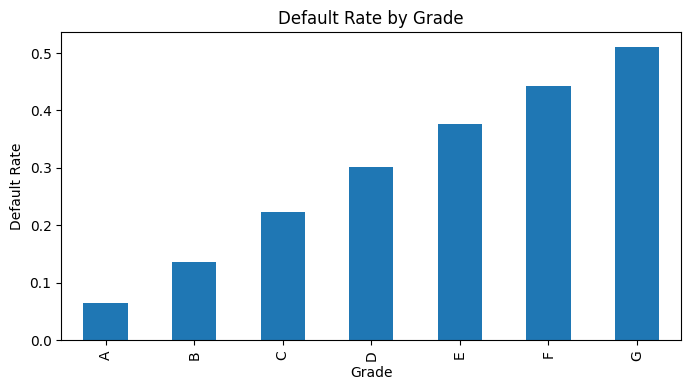

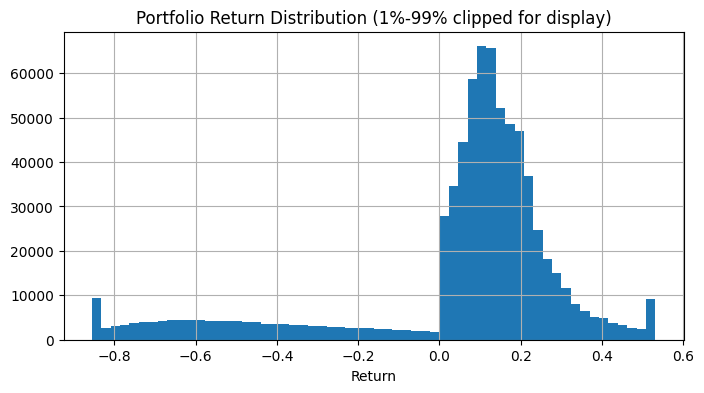

,missing_rate
next_pymnt_d,0.9998
hardship_loan_status,0.9931
hardship_start_date,0.9931
hardship_type,0.9931
payment_plan_start_date,0.9931
hardship_status,0.9931
deferral_term,0.9931
hardship_length,0.9931
hardship_end_date,0.9931
hardship_dpd,0.9931


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
df["default"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax)
ax.set_title("Default Class Distribution")
ax.set_xlabel("Default")
ax.set_ylabel("Proportion")
plt.show()

if "grade" in df.columns:
    grade_default = (
        df.groupby("grade", observed=True)["default"]
        .agg(["count", "mean"])
        .sort_index()
    )
    display(grade_default)

    fig, ax = plt.subplots(figsize=(8, 4))
    grade_default["mean"].plot(kind="bar", ax=ax)
    ax.set_title("Default Rate by Grade")
    ax.set_xlabel("Grade")
    ax.set_ylabel("Default Rate")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df["portfolio_return"].clip(
    lower=df["portfolio_return"].quantile(0.01),
    upper=df["portfolio_return"].quantile(0.99),
).hist(bins=60, ax=ax)
ax.set_title("Portfolio Return Distribution (1%-99% clipped for display)")
ax.set_xlabel("Return")
plt.show()

missing_report = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
display(missing_report.head(30))

## 6. 시간순 데이터 분리

무작위 6:2:2 분할 대신 **과거로 학습하고 미래를 평가**합니다.  
지정 연도가 존재하지 않으면 `issue_date` 기준 60%/20%/20% 순차 분할로 자동 전환합니다.

In [11]:
def chronological_split(df):
    if "issue_year" not in df.columns or df["issue_year"].notna().sum() == 0:
        raise ValueError("No valid issue date is available for chronological splitting.")

    train = df[df["issue_year"] <= TRAIN_END_YEAR].copy()
    valid = df[df["issue_year"] == VALID_YEAR].copy()
    test = df[df["issue_year"] == TEST_YEAR].copy()

    if min(len(train), len(valid), len(test)) > 0:
        split_method = (
            f"Year split: train <= {TRAIN_END_YEAR}, "
            f"validation = {VALID_YEAR}, test = {TEST_YEAR}"
        )
        return train, valid, test, split_method

    ordered = df.sort_values("issue_date").copy()
    n = len(ordered)
    train_end = int(n * 0.60)
    valid_end = int(n * 0.80)

    train = ordered.iloc[:train_end].copy()
    valid = ordered.iloc[train_end:valid_end].copy()
    test = ordered.iloc[valid_end:].copy()
    split_method = "Fallback chronological 60/20/20 split"
    return train, valid, test, split_method


train_df, valid_df, test_df, split_method = chronological_split(df)

print(split_method)
print("Train:", train_df.shape, train_df["issue_year"].min(), train_df["issue_year"].max())
print("Valid:", valid_df.shape, valid_df["issue_year"].min(), valid_df["issue_year"].max())
print("Test :", test_df.shape, test_df["issue_year"].min(), test_df["issue_year"].max())

if min(len(train_df), len(valid_df), len(test_df)) == 0:
    raise ValueError("At least one split is empty.")

Year split: train <= 2014, validation = 2015, test = 2016
Train: (180809, 157) 2007 2014
Valid: (157573, 157) 2015 2015
Test : (157638, 157) 2016 2016


## 7. 누수변수 제거

아래 변수들은 대출 실행 후에 발생한 상환·연체·회수 결과 또는 타겟을 직접적으로 드러내므로 모델 입력에서 제외합니다.

`grade`, `sub_grade`, `int_rate`는 사후변수는 아니지만 Lending Club의 기존 심사 결과를 반영한 변수입니다. 따라서:

- **Traditional baseline**에는 사용
- **Proposed model**에서는 제거
- **Hybrid model**에서는 포함

으로 구분합니다.

In [12]:
TARGET_AND_RETURN_COLUMNS = {
    "default", "loan_status", "simple_return", "approx_annual_irr",
    "portfolio_return", "extreme_return_flag"
}

DATE_RAW_COLUMNS = {
    "issue_d", "issue_date", "earliest_cr_line", "earliest_credit_date"
}

IDENTIFIER_COLUMNS = {
    "id", "member_id", "url", "desc", "title", "emp_title",
    "zip_code", "addr_state"
}

# Post-origination outcome variables: strict leakage removal
POST_LOAN_LEAKAGE_COLUMNS = {
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d",
    "pymnt_plan", "hardship_flag", "hardship_type",
    "hardship_reason", "hardship_status", "deferral_term",
    "hardship_amount", "hardship_start_date", "hardship_end_date",
    "payment_plan_start_date", "hardship_length", "hardship_dpd",
    "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term",
}

# Traditional LC decision information
TRADITIONAL_CANDIDATES = [
    "grade", "sub_grade", "int_rate", "loan_amnt", "term_months"
]

# Variables known or plausibly available at application/origination.
# Unknown columns are handled conservatively by removing explicit leakage first.
ALL_EXCLUDED_COLUMNS = (
    TARGET_AND_RETURN_COLUMNS
    | DATE_RAW_COLUMNS
    | IDENTIFIER_COLUMNS
    | POST_LOAN_LEAKAGE_COLUMNS
)

present_leakage = sorted(set(df.columns) & POST_LOAN_LEAKAGE_COLUMNS)
print("Detected post-loan leakage columns:", len(present_leakage))
print(present_leakage)

Detected post-loan leakage columns: 30
['collection_recovery_fee', 'debt_settlement_flag', 'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_flag', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'last_credit_pull_d', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d', 'orig_projected_additional_accrued_interest', 'out_prncp', 'out_prncp_inv', 'payment_plan_start_date', 'pymnt_plan', 'recoveries', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp']


## 8. 결측치·고유값·상관관계 기반 변수 정리

중요한 원칙은 **Train 데이터만으로 제거 기준을 결정**한 뒤 Validation/Test에 동일하게 적용하는 것입니다.

In [13]:
def get_initial_feature_columns(train_df):
    return [
        col for col in train_df.columns
        if col not in ALL_EXCLUDED_COLUMNS
    ]


def fit_feature_filter(train_df, candidate_columns):
    report = {}

    missing_rates = train_df[candidate_columns].isna().mean()
    high_missing = missing_rates[missing_rates > MISSING_THRESHOLD].index.tolist()

    remaining = [c for c in candidate_columns if c not in high_missing]

    nunique = train_df[remaining].nunique(dropna=True)
    constant_columns = nunique[nunique <= 1].index.tolist()
    remaining = [c for c in remaining if c not in constant_columns]

    high_cardinality = []
    for col in remaining:
        if train_df[col].dtype == "object":
            levels = train_df[col].nunique(dropna=True)
            if levels > MAX_CATEGORY_LEVELS:
                high_cardinality.append(col)

    remaining = [c for c in remaining if c not in high_cardinality]

    # Numeric correlation filter
    numeric_columns = train_df[remaining].select_dtypes(include=np.number).columns.tolist()
    corr_drop = []

    if len(numeric_columns) >= 2:
        corr_matrix = train_df[numeric_columns].corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        corr_drop = [
            column for column in upper.columns
            if any(upper[column] > CORR_THRESHOLD)
        ]

    remaining = [c for c in remaining if c not in corr_drop]

    report["high_missing"] = high_missing
    report["constant"] = constant_columns
    report["high_cardinality"] = high_cardinality
    report["high_correlation"] = corr_drop
    report["kept"] = remaining
    return report


initial_features = get_initial_feature_columns(train_df)
feature_filter_report = fit_feature_filter(train_df, initial_features)
filtered_features = feature_filter_report["kept"]

print("Initial candidate features:", len(initial_features))
for key in ["high_missing", "constant", "high_cardinality", "high_correlation"]:
    print(f"{key}: {len(feature_filter_report[key])}")
print("Final filtered features:", len(filtered_features))

feature_filter_summary = pd.DataFrame({
    "reason": [
        "high_missing", "constant", "high_cardinality", "high_correlation", "kept"
    ],
    "count": [
        len(feature_filter_report["high_missing"]),
        len(feature_filter_report["constant"]),
        len(feature_filter_report["high_cardinality"]),
        len(feature_filter_report["high_correlation"]),
        len(feature_filter_report["kept"]),
    ]
})
display(feature_filter_summary)

Initial candidate features: 112
high_missing: 34
constant: 2
high_cardinality: 0
high_correlation: 11
Final filtered features: 65


,reason,count
0,high_missing,34
1,constant,2
2,high_cardinality,0
3,high_correlation,11
4,kept,65


## 9. 비교할 변수 집합 정의

- `traditional_features`: Lending Club 등급·금리 중심
- `proposed_features`: 등급·금리를 제외한 신청자 정보
- `hybrid_features`: 두 정보 모두 사용

`Traditional`과 `Proposed`의 비교가 메인 가설 검증입니다.

In [14]:
traditional_features = [
    col for col in TRADITIONAL_CANDIDATES
    if col in filtered_features
]

lc_decision_columns = {"grade", "sub_grade", "int_rate"}

proposed_features = [
    col for col in filtered_features
    if col not in lc_decision_columns
]

hybrid_features = filtered_features.copy()

if len(traditional_features) == 0:
    raise ValueError(
        "No traditional baseline feature is available. "
        "Check grade/sub_grade/int_rate/loan_amnt columns."
    )

if len(proposed_features) == 0:
    raise ValueError("No proposed-model feature remains after filtering.")

print("Traditional features:", traditional_features)
print("Proposed feature count:", len(proposed_features))
print("Hybrid feature count:", len(hybrid_features))

Traditional features: ['grade', 'sub_grade', 'int_rate', 'loan_amnt', 'term_months']
Proposed feature count: 62
Hybrid feature count: 65


## 10. 전처리기와 모델 정의

In [15]:
def make_preprocessor(df, feature_columns):
    numeric_columns = (
        df[feature_columns]
        .select_dtypes(include=np.number)
        .columns.tolist()
    )
    categorical_columns = [
        col for col in feature_columns
        if col not in numeric_columns
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10,
            sparse_output=True,
        )),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

    return preprocessor, numeric_columns, categorical_columns


def build_pipeline(model, df, feature_columns):
    preprocessor, numeric_columns, categorical_columns = make_preprocessor(
        df, feature_columns
    )
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    return pipeline, numeric_columns, categorical_columns


model_specs = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        max_depth=14,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),
}

## 11. 모델 학습

계산량을 줄이기 위해:

- Traditional baseline: Logistic Regression
- Proposed: Logistic Regression, Random Forest, LightGBM
- Hybrid: LightGBM

을 학습합니다.

In [16]:
experiments = {
    "Traditional Logistic": {
        "features": traditional_features,
        "model": model_specs["Logistic Regression"],
        "group": "Traditional",
    },
    "Proposed Logistic": {
        "features": proposed_features,
        "model": model_specs["Logistic Regression"],
        "group": "Proposed",
    },
    "Proposed Random Forest": {
        "features": proposed_features,
        "model": model_specs["Random Forest"],
        "group": "Proposed",
    },
    "Proposed LightGBM": {
        "features": proposed_features,
        "model": model_specs["LightGBM"],
        "group": "Proposed",
    },
    "Hybrid LightGBM": {
        "features": hybrid_features,
        "model": model_specs["LightGBM"],
        "group": "Hybrid",
    },
}

trained_models = {}
validation_probabilities = {}
test_probabilities = {}

y_train = train_df["default"].astype(int)
y_valid = valid_df["default"].astype(int)
y_test = test_df["default"].astype(int)

for experiment_name, spec in experiments.items():
    print(f"Training: {experiment_name}")
    feature_columns = spec["features"]

    pipeline, numeric_columns, categorical_columns = build_pipeline(
        spec["model"], train_df, feature_columns
    )

    pipeline.fit(train_df[feature_columns], y_train)

    trained_models[experiment_name] = pipeline
    validation_probabilities[experiment_name] = pipeline.predict_proba(
        valid_df[feature_columns]
    )[:, 1]
    test_probabilities[experiment_name] = pipeline.predict_proba(
        test_df[feature_columns]
    )[:, 1]

print("All models trained.")

Training: Traditional Logistic
Training: Proposed Logistic
Training: Proposed Random Forest
Training: Proposed LightGBM
Training: Hybrid LightGBM
All models trained.


## 12. 분류 성능 평가

AUC는 참고 지표이며, 최종 모델 선택은 Validation Sharpe Ratio로 수행합니다.

In [17]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
    }


classification_rows = []

for experiment_name in experiments:
    valid_metrics = classification_metrics(
        y_valid, validation_probabilities[experiment_name], threshold=0.5
    )
    test_metrics = classification_metrics(
        y_test, test_probabilities[experiment_name], threshold=0.5
    )

    classification_rows.append({
        "model": experiment_name,
        "group": experiments[experiment_name]["group"],
        "validation_auc": valid_metrics["auc"],
        "validation_ap": valid_metrics["average_precision"],
        "test_auc": test_metrics["auc"],
        "test_ap": test_metrics["average_precision"],
    })

classification_results = pd.DataFrame(classification_rows).sort_values(
    "validation_auc", ascending=False
)
display(classification_results)

,model,group,validation_auc,validation_ap,test_auc,test_ap
4,Hybrid LightGBM,Hybrid,0.9403,0.7843,0.9453,0.8027
3,Proposed LightGBM,Proposed,0.9403,0.7843,0.9455,0.8039
2,Proposed Random Forest,Proposed,0.9373,0.7691,0.9425,0.7899
1,Proposed Logistic,Proposed,0.9366,0.7603,0.9427,0.7793
0,Traditional Logistic,Traditional,0.7070,0.3601,0.7014,0.3628


## 13. 포트폴리오 성과 함수와 임계값 최적화

모델이 예측한 부도확률이 임계값보다 낮은 대출만 승인한다고 가정합니다.

Sharpe Ratio:

\[
\text{Sharpe} =
\frac{\text{평균 포트폴리오 수익률} - \text{무위험수익률}}
{\text{포트폴리오 수익률의 표준편차}}
\]

한 대출마다 Sharpe Ratio를 구하는 것이 아니라, **승인된 전체 대출 포트폴리오에서 하나의 Sharpe Ratio**를 구합니다.

In [18]:
def evaluate_portfolio(df, probabilities=None, threshold=None):
    if probabilities is None:
        approved_mask = np.ones(len(df), dtype=bool)
    else:
        approved_mask = np.asarray(probabilities) < threshold

    approved = df.loc[approved_mask].copy()
    total_count = len(df)
    approved_count = len(approved)

    if approved_count == 0:
        return None

    returns = approved["portfolio_return"].dropna()

    if len(returns) < 2:
        return None

    return_std = returns.std(ddof=1)
    sharpe = (
        (returns.mean() - RISK_FREE_RATE) / return_std
        if return_std > 0
        else np.nan
    )

    return {
        "threshold": threshold,
        "total_loans": total_count,
        "approved_loans": approved_count,
        "approval_rate": approved_count / total_count,
        "default_rate": approved["default"].mean(),
        "mean_return": returns.mean(),
        "median_return": returns.median(),
        "return_std": return_std,
        "sharpe_ratio": sharpe,
        "total_invested": pd.to_numeric(
            approved.get(
                "funded_amnt_inv",
                approved.get("funded_amnt", approved.get("loan_amnt", np.nan))
            ),
            errors="coerce",
        ).sum(),
    }


def optimize_threshold(df, probabilities):
    rows = []

    for threshold in THRESHOLD_GRID:
        result = evaluate_portfolio(df, probabilities, threshold)

        if result is None:
            continue

        if result["approval_rate"] < MIN_APPROVAL_RATE:
            continue

        if result["approved_loans"] < MIN_APPROVED_LOANS:
            continue

        if not np.isfinite(result["sharpe_ratio"]):
            continue

        rows.append(result)

    result_df = pd.DataFrame(rows)

    if result_df.empty:
        raise ValueError(
            "No valid threshold satisfies the approval constraints. "
            "Lower MIN_APPROVAL_RATE or MIN_APPROVED_LOANS."
        )

    best_row = result_df.loc[result_df["sharpe_ratio"].idxmax()].copy()
    return result_df, best_row


validation_threshold_curves = {}
best_thresholds = {}
validation_portfolio_rows = []

for experiment_name, probabilities in validation_probabilities.items():
    curve, best_row = optimize_threshold(valid_df, probabilities)
    validation_threshold_curves[experiment_name] = curve
    best_thresholds[experiment_name] = float(best_row["threshold"])

    row = best_row.to_dict()
    row["model"] = experiment_name
    row["group"] = experiments[experiment_name]["group"]
    validation_portfolio_rows.append(row)

validation_portfolio_results = pd.DataFrame(validation_portfolio_rows).sort_values(
    "sharpe_ratio", ascending=False
)

display(validation_portfolio_results[
    [
        "model", "group", "threshold", "approval_rate",
        "default_rate", "mean_return", "return_std", "sharpe_ratio"
    ]
])

,model,group,threshold,approval_rate,default_rate,mean_return,return_std,sharpe_ratio
2,Proposed Random Forest,Proposed,0.0500,0.1403,0.0028,0.1092,0.0615,1.7772
1,Proposed Logistic,Proposed,0.0200,0.1032,0.0022,0.1206,0.0708,1.7042
4,Hybrid LightGBM,Hybrid,0.0100,0.1068,0.0017,0.1305,0.0810,1.6105
3,Proposed LightGBM,Proposed,0.0200,0.2302,0.0025,0.1441,0.0953,1.5121
0,Traditional Logistic,Traditional,0.2400,0.1004,0.0403,0.0664,0.1035,0.6416


## 14. 임계값별 Sharpe 곡선

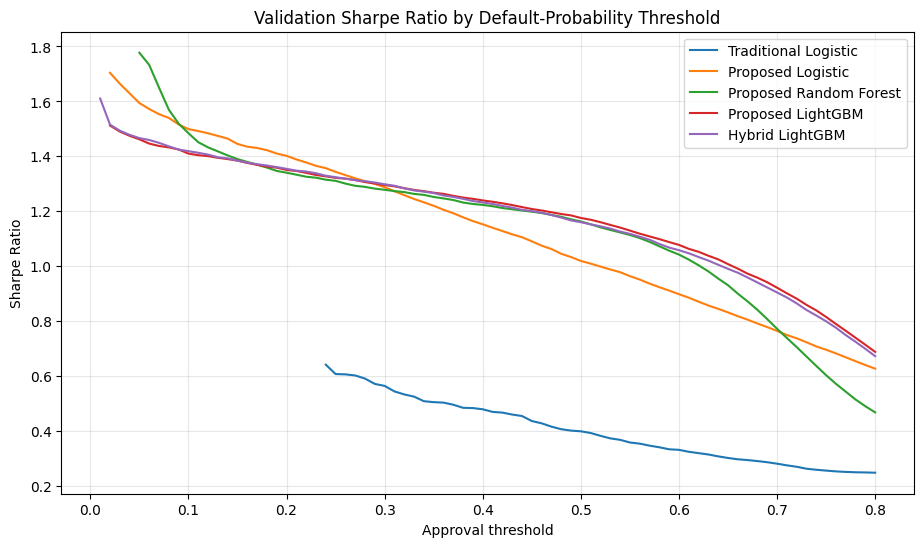

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

for experiment_name, curve in validation_threshold_curves.items():
    ax.plot(
        curve["threshold"],
        curve["sharpe_ratio"],
        label=experiment_name,
    )

ax.set_title("Validation Sharpe Ratio by Default-Probability Threshold")
ax.set_xlabel("Approval threshold")
ax.set_ylabel("Sharpe Ratio")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 15. Test 데이터 최종 평가

Validation에서 고른 임계값을 Test에 그대로 적용합니다.  
Test 결과를 보고 임계값을 다시 바꾸면 데이터 누수가 됩니다.

In [20]:
test_portfolio_rows = []

all_loans_result = evaluate_portfolio(test_df)
all_loans_result["model"] = "All Loans Benchmark"
all_loans_result["group"] = "Benchmark"
test_portfolio_rows.append(all_loans_result)

for experiment_name, probabilities in test_probabilities.items():
    threshold = best_thresholds[experiment_name]
    result = evaluate_portfolio(test_df, probabilities, threshold)

    row = result.copy()
    row["model"] = experiment_name
    row["group"] = experiments[experiment_name]["group"]
    test_portfolio_rows.append(row)

test_portfolio_results = pd.DataFrame(test_portfolio_rows)

test_portfolio_results["sharpe_improvement_vs_all"] = (
    test_portfolio_results["sharpe_ratio"]
    - all_loans_result["sharpe_ratio"]
)

test_portfolio_results = test_portfolio_results.sort_values(
    "sharpe_ratio", ascending=False
)

display(test_portfolio_results[
    [
        "model", "group", "threshold", "approved_loans", "approval_rate",
        "default_rate", "mean_return", "return_std", "sharpe_ratio",
        "sharpe_improvement_vs_all"
    ]
])

,model,group,threshold,approved_loans,approval_rate,default_rate,mean_return,return_std,sharpe_ratio,sharpe_improvement_vs_all
3,Proposed Random Forest,Proposed,0.0500,23668,0.1501,0.0035,0.1072,0.0663,1.6158,1.4294
5,Hybrid LightGBM,Hybrid,0.0100,15897,0.1008,0.0021,0.1204,0.0755,1.5954,1.4090
2,Proposed Logistic,Proposed,0.0200,18013,0.1143,0.0037,0.1156,0.0730,1.5848,1.3984
4,Proposed LightGBM,Proposed,0.0200,35868,0.2275,0.0032,0.1312,0.0865,1.5161,1.3297
1,Traditional Logistic,Traditional,0.2400,17118,0.1086,0.0448,0.0603,0.1166,0.5172,0.3308
0,All Loans Benchmark,Benchmark,NaN,157638,1.0000,0.1962,0.0502,0.2692,0.1864,0.0000


## 16. 메인 가설 판정

`Traditional Logistic`과 가장 성과가 좋은 `Proposed` 모델의 Test Sharpe Ratio를 비교합니다.

주의: 단순히 값이 높다고 통계적으로 “증명”된 것은 아닙니다. 다음 Bootstrap에서 차이의 신뢰구간도 확인합니다.

In [21]:
traditional_test = test_portfolio_results[
    test_portfolio_results["model"] == "Traditional Logistic"
].iloc[0]

best_proposed_test = (
    test_portfolio_results[
        test_portfolio_results["group"] == "Proposed"
    ]
    .sort_values("sharpe_ratio", ascending=False)
    .iloc[0]
)

hypothesis_summary = pd.DataFrame([
    {
        "strategy": "Traditional baseline",
        "model": traditional_test["model"],
        "sharpe_ratio": traditional_test["sharpe_ratio"],
        "approval_rate": traditional_test["approval_rate"],
        "default_rate": traditional_test["default_rate"],
        "mean_return": traditional_test["mean_return"],
    },
    {
        "strategy": "Best proposed model",
        "model": best_proposed_test["model"],
        "sharpe_ratio": best_proposed_test["sharpe_ratio"],
        "approval_rate": best_proposed_test["approval_rate"],
        "default_rate": best_proposed_test["default_rate"],
        "mean_return": best_proposed_test["mean_return"],
    },
])

display(hypothesis_summary)

difference = (
    best_proposed_test["sharpe_ratio"]
    - traditional_test["sharpe_ratio"]
)

print(f"Sharpe difference (Proposed - Traditional): {difference:.4f}")

if difference > 0:
    print(
        "현재 Test 표본에서는 Proposed model의 Sharpe Ratio가 더 높습니다. "
        "Bootstrap 신뢰구간으로 결과 안정성을 추가 확인하세요."
    )
else:
    print(
        "현재 Test 표본에서는 메인 가설을 지지하지 않습니다. "
        "변수·모델·수익률 정의를 결과에 맞춰 임의 변경하면 안 됩니다."
    )

,strategy,model,sharpe_ratio,approval_rate,default_rate,mean_return
0,Traditional baseline,Traditional Logistic,0.5172,0.1086,0.0448,0.0603
1,Best proposed model,Proposed Random Forest,1.6158,0.1501,0.0035,0.1072


Sharpe difference (Proposed - Traditional): 1.0986
현재 Test 표본에서는 Proposed model의 Sharpe Ratio가 더 높습니다. Bootstrap 신뢰구간으로 결과 안정성을 추가 확인하세요.


## 17. Bootstrap 안정성 검증

동일한 Test 대출들을 복원추출하여 Sharpe Ratio 차이의 분포를 구합니다.

- 신뢰구간 전체가 0보다 크면 Proposed 모델의 우위가 비교적 안정적
- 0을 포함하면 표본에 따라 우위가 바뀔 수 있음

,traditional_model,proposed_model,mean_sharpe_difference,std_sharpe_difference,95%_ci_low,95%_ci_high,probability_difference_positive,valid_bootstrap_samples
0,Traditional Logistic,Proposed Random Forest,1.0992,0.0433,1.0177,1.1830,1.0000,300


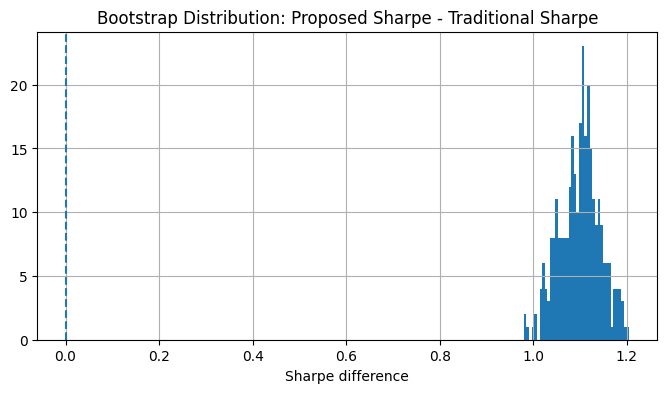

In [22]:
def bootstrap_strategy_difference(
    df,
    probabilities_a,
    threshold_a,
    probabilities_b,
    threshold_b,
    n_bootstraps=N_BOOTSTRAPS,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    n = len(df)
    rows = []

    probabilities_a = np.asarray(probabilities_a)
    probabilities_b = np.asarray(probabilities_b)

    for iteration in range(n_bootstraps):
        idx = rng.integers(0, n, size=n)
        sampled_df = df.iloc[idx].reset_index(drop=True)

        result_a = evaluate_portfolio(
            sampled_df, probabilities_a[idx], threshold_a
        )
        result_b = evaluate_portfolio(
            sampled_df, probabilities_b[idx], threshold_b
        )

        if result_a is None or result_b is None:
            continue

        if not (
            np.isfinite(result_a["sharpe_ratio"])
            and np.isfinite(result_b["sharpe_ratio"])
        ):
            continue

        rows.append({
            "iteration": iteration,
            "traditional_sharpe": result_a["sharpe_ratio"],
            "proposed_sharpe": result_b["sharpe_ratio"],
            "sharpe_difference": (
                result_b["sharpe_ratio"] - result_a["sharpe_ratio"]
            ),
        })

    return pd.DataFrame(rows)


best_proposed_name = best_proposed_test["model"]

bootstrap_results = bootstrap_strategy_difference(
    test_df.reset_index(drop=True),
    test_probabilities["Traditional Logistic"],
    best_thresholds["Traditional Logistic"],
    test_probabilities[best_proposed_name],
    best_thresholds[best_proposed_name],
)

if bootstrap_results.empty:
    raise ValueError("Bootstrap produced no valid samples.")

ci_low, ci_high = bootstrap_results["sharpe_difference"].quantile([0.025, 0.975])
bootstrap_summary = pd.DataFrame([{
    "traditional_model": "Traditional Logistic",
    "proposed_model": best_proposed_name,
    "mean_sharpe_difference": bootstrap_results["sharpe_difference"].mean(),
    "std_sharpe_difference": bootstrap_results["sharpe_difference"].std(ddof=1),
    "95%_ci_low": ci_low,
    "95%_ci_high": ci_high,
    "probability_difference_positive": (
        bootstrap_results["sharpe_difference"] > 0
    ).mean(),
    "valid_bootstrap_samples": len(bootstrap_results),
}])

display(bootstrap_summary)

fig, ax = plt.subplots(figsize=(8, 4))
bootstrap_results["sharpe_difference"].hist(bins=40, ax=ax)
ax.axvline(0, linestyle="--")
ax.set_title("Bootstrap Distribution: Proposed Sharpe - Traditional Sharpe")
ax.set_xlabel("Sharpe difference")
plt.show()

## 18. Feature importance

LightGBM의 전처리 후 변수 중요도를 확인합니다.  
원-핫 인코딩된 범주형 변수는 각 범주 수준별로 표시될 수 있습니다.

In [26]:
def extract_feature_importance(model, top_n=30):
    """
    학습된 Pipeline 또는 LightGBM 모델에서
    feature importance를 안전하게 추출하는 함수
    """

    # Pipeline인 경우 마지막 모델 추출
    if hasattr(model, "named_steps"):
        final_model = list(model.named_steps.values())[-1]
    else:
        final_model = model

    # LightGBM booster가 저장한 실제 특성 이름 사용
    if hasattr(final_model, "booster_"):
        feature_names = final_model.booster_.feature_name()
        feature_importances = final_model.feature_importances_

    # 일반적인 트리 모델
    elif hasattr(final_model, "feature_importances_"):
        feature_importances = final_model.feature_importances_
        feature_names = [
            f"feature_{i}"
            for i in range(len(feature_importances))
        ]

    else:
        raise ValueError(
            "이 모델에서는 feature importance를 추출할 수 없습니다."
        )

    # 혹시 길이가 다르면 짧은 쪽에 맞춤
    min_length = min(
        len(feature_names),
        len(feature_importances)
    )

    feature_names = feature_names[:min_length]
    feature_importances = feature_importances[:min_length]

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importances
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return importance_df

proposed_lgbm_importance = extract_feature_importance(
    trained_models["Proposed LightGBM"],
    top_n=30
)

display(proposed_lgbm_importance)

,feature,importance
0,Column_12,1600
1,Column_55,873
2,Column_1,581
3,Column_3,541
4,Column_26,477
5,Column_51,472
6,Column_2,425
7,Column_11,402
8,Column_56,399
9,Column_25,384


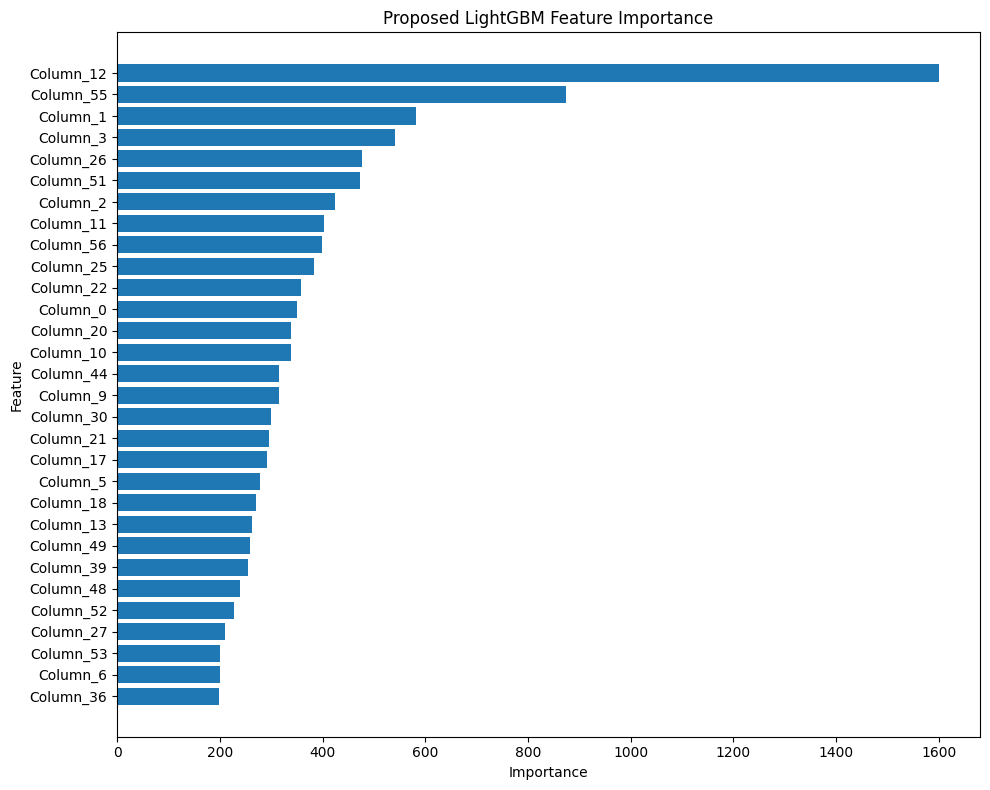

In [27]:
plt.figure(figsize=(10, 8))

plt.barh(
    proposed_lgbm_importance["feature"][::-1],
    proposed_lgbm_importance["importance"][::-1]
)

plt.title("Proposed LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 19. Leakage 진단 실험

이 실험은 사후변수를 포함한 잘못된 모델을 의도적으로 만들어 성능이 비정상적으로 높아지는지 확인합니다.

- 정상 분석 결과로 사용하면 안 됩니다.
- “왜 누수변수를 제거해야 하는가”를 발표에서 보여주는 진단용입니다.

In [28]:
diagnostic_leakage_candidates = [
    col for col in [
        "total_pymnt", "total_pymnt_inv", "recoveries",
        "collection_recovery_fee", "last_pymnt_amnt",
        "total_rec_prncp", "out_prncp"
    ]
    if col in train_df.columns
]

if diagnostic_leakage_candidates:
    diagnostic_features = list(dict.fromkeys(
        proposed_features + diagnostic_leakage_candidates
    ))

    leakage_pipeline, _, _ = build_pipeline(
        model_specs["LightGBM"],
        train_df,
        diagnostic_features,
    )

    leakage_pipeline.fit(
        train_df[diagnostic_features],
        y_train,
    )

    leakage_valid_probability = leakage_pipeline.predict_proba(
        valid_df[diagnostic_features]
    )[:, 1]

    leakage_auc = roc_auc_score(y_valid, leakage_valid_probability)
    clean_auc = roc_auc_score(
        y_valid,
        validation_probabilities["Proposed LightGBM"],
    )

    leakage_diagnostic = pd.DataFrame([
        {
            "model": "Clean Proposed LightGBM",
            "validation_auc": clean_auc,
            "contains_post_loan_leakage": False,
        },
        {
            "model": "Diagnostic Leaky LightGBM",
            "validation_auc": leakage_auc,
            "contains_post_loan_leakage": True,
        },
    ])

    display(leakage_diagnostic)
    print("Added leakage variables:", diagnostic_leakage_candidates)
else:
    print(
        "No post-loan leakage column remains in the loaded dataframe, "
        "so the diagnostic experiment was skipped."
    )

,model,validation_auc,contains_post_loan_leakage
0,Clean Proposed LightGBM,0.9403,False
1,Diagnostic Leaky LightGBM,0.9999,True


Added leakage variables: ['total_pymnt', 'total_pymnt_inv', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'total_rec_prncp', 'out_prncp']


## 20. 최종 결과 시각화

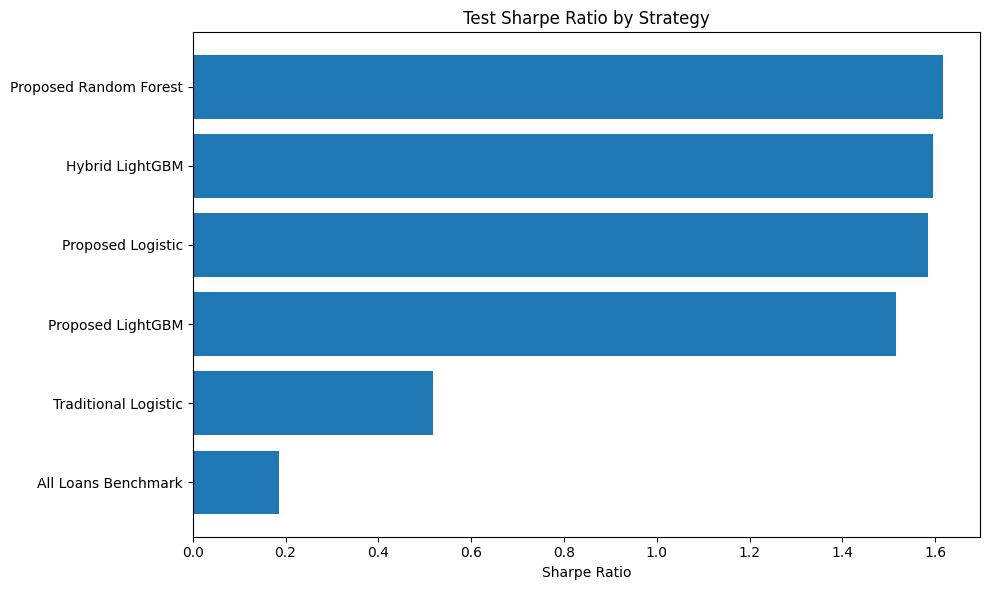

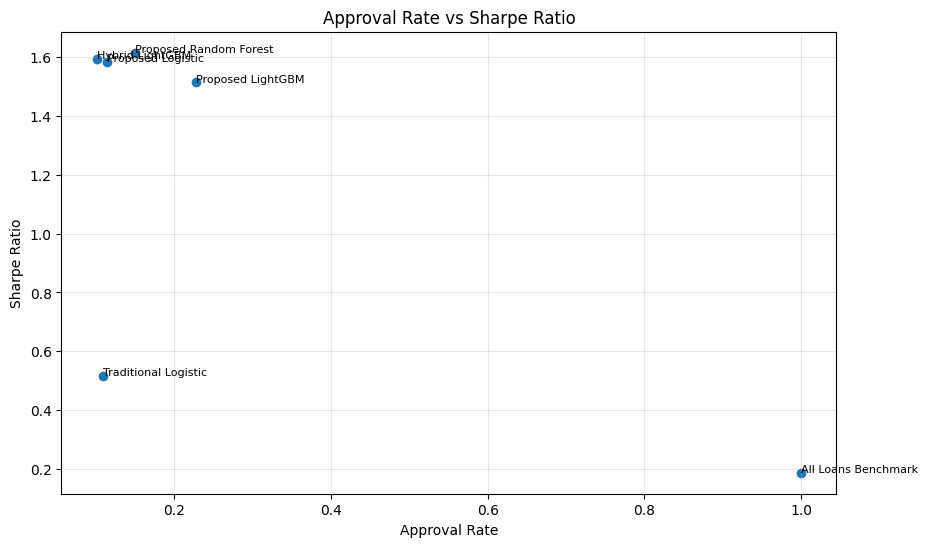

In [29]:
plot_results = test_portfolio_results.sort_values("sharpe_ratio")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_results["model"], plot_results["sharpe_ratio"])
ax.set_title("Test Sharpe Ratio by Strategy")
ax.set_xlabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    test_portfolio_results["approval_rate"],
    test_portfolio_results["sharpe_ratio"],
)

for _, row in test_portfolio_results.iterrows():
    ax.annotate(
        row["model"],
        (row["approval_rate"], row["sharpe_ratio"]),
        fontsize=8,
    )

ax.set_title("Approval Rate vs Sharpe Ratio")
ax.set_xlabel("Approval Rate")
ax.set_ylabel("Sharpe Ratio")
ax.grid(alpha=0.3)
plt.show()

# 결과 해석 순서

실행이 끝나면 다음 순서로 확인합니다.

1. `Detected post-loan leakage columns`  
   사후변수가 입력에서 제외되었는지 확인합니다.

2. `classification_results`  
   각 모델의 AUC와 Average Precision을 확인합니다. 단, 최종 선택 기준은 아닙니다.

3. `validation_portfolio_results`  
   Validation에서 각 모델의 최적 승인 임계값을 확인합니다.

4. `test_portfolio_results`  
   모든 대출, Traditional, Proposed, Hybrid의 최종 Sharpe Ratio를 비교합니다.

5. `hypothesis_summary`  
   Traditional과 가장 좋은 Proposed 모델의 차이를 확인합니다.

6. `bootstrap_summary`  
   `95%_ci_low`와 `95%_ci_high`가 모두 0보다 큰지 확인합니다.

7. `proposed_lgbm_importance`  
   Proposed 모델이 어떤 신청자 정보를 중요하게 사용했는지 설명합니다.

## 발표 결론 문장 템플릿

### Proposed가 우수하고 Bootstrap 신뢰구간도 0보다 큰 경우

> 기존 신용등급 중심의 심사 전략과 비교했을 때, 다양한 대출 신청 정보를 활용한 머신러닝 전략은 Test 포트폴리오의 Sharpe Ratio를 높였다. Bootstrap 분석에서도 Sharpe Ratio 차이의 95% 신뢰구간이 0보다 크게 나타나, 해당 개선이 표본 재추출에도 비교적 안정적으로 유지됨을 확인하였다.

### Proposed 값은 높지만 신뢰구간이 0을 포함하는 경우

> Test 표본에서는 머신러닝 전략의 Sharpe Ratio가 기존 전략보다 높았으나, Bootstrap 신뢰구간이 0을 포함하였다. 따라서 성과 개선 가능성은 확인했지만, 우위가 통계적으로 안정적이라고 단정하기는 어렵다.

### Proposed가 더 낮은 경우

> 다양한 신청 정보를 활용한 머신러닝 모델이 분류 성능에서는 경쟁력을 보였으나, 포트폴리오 Sharpe Ratio는 기존 전략을 넘지 못했다. 이는 부도 분류 성능 향상이 위험 대비 수익성 개선으로 반드시 이어지지는 않음을 보여준다.